In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
%matplotlib inline
import getdist
from getdist import loadMCSamples, plots
import warnings
from copy import deepcopy

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['ytick.major.size'] = 6
matplotlib.rcParams['ytick.major.width'] = 1.2
matplotlib.rcParams['ytick.minor.size'] = 3
matplotlib.rcParams['ytick.minor.width'] = 0.8
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 24
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['legend.fontsize'] = 14
matplotlib.rcParams['legend.title_fontsize'] = 18
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.dpi'] = 300

columnwidth=246/72.27
textwidth=510/72.27

matplotlib.rcParams['axes.titlesize'] = 10
matplotlib.rcParams['axes.labelsize'] = 10
matplotlib.rcParams['legend.fontsize'] = 10
matplotlib.rcParams['legend.title_fontsize'] = 10
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10

from scipy.interpolate import interp1d
from scipy.integrate import quad

In [2]:
dv_filepaths = [
    './data/roman_baseline_evaluate/roman.modelvector',
    './data/roman_limber_evaluate/roman.modelvector',
    './data/roman_noRSD_evaluate/roman.modelvector',
    './data/roman_hmcode20_evaluate/roman.modelvector',
    './data/roman_limber_noRSD_hmcode20_evaluate/roman.modelvector',
]
cov_filepath = './data/cov_roman'
Y3mask_filepath = './data/roman_Y3.mask'
SRDmask_filepath = './data/roman_SRD.mask'

dvs = []
for i in range(len(dv_filepaths)):
    dvs.append(np.loadtxt(dv_filepaths[i])[:,1]) 
dvs = np.array(dvs)

cov_raw = np.loadtxt(cov_filepath)
ncov = int(np.max(cov_raw[:,0])+1)
cov = np.zeros((ncov, ncov))
for i in range(len(cov_raw)):
    ii = int(cov_raw[i,0])
    jj = int(cov_raw[i,1])
    element = cov_raw[i,8] + cov_raw[i,9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
y3mask = np.loadtxt(Y3mask_filepath)[:,1].astype(bool)
srdmask = np.loadtxt(SRDmask_filepath)[:,1].astype(bool)

chi2s_origin, chi2s_y3mask, chi2s_srdmask = [], [], []
invcov = np.linalg.pinv(cov)
invcov_y3 = np.linalg.pinv(cov[y3mask,:][:,y3mask])
invcov_srd = np.linalg.pinv(cov[srdmask,:][:,srdmask])
for i in range(len(dv_filepaths)):
    chi2s_origin.append((dvs[i]-dvs[0])@invcov@(dvs[i]-dvs[0]))
    chi2s_y3mask.append((dvs[i]-dvs[0])[y3mask]@invcov_y3@(dvs[i]-dvs[0])[y3mask])
    chi2s_srdmask.append((dvs[i]-dvs[0])[srdmask]@invcov_srd@(dvs[i]-dvs[0])[srdmask])


### Calculate the S/N for probes

In [ ]:
nlens = 10
nsrcs = 8
ntheta = 20

baseline = dvs[0]

starts = [
    0,
    int(nsrcs*(nsrcs+1)/2*ntheta),
    int(nsrcs*(nsrcs+1)*ntheta),
    int(nsrcs*(nsrcs+1)*ntheta+nlens*nsrcs*ntheta),
    int(nsrcs*(nsrcs+1)*ntheta+nlens*nsrcs*ntheta+nlens*ntheta)
]

probes = [
    'xi+',
    'xi-',
    'gammat',
    'wtheta',
]

chi2_total = baseline[y3mask] @ invcov_y3 @ baseline[y3mask]

for i in range(len(starts)-1):
    l = starts[i]
    r = starts[i+1]

    seg_mask = y3mask[l:r]
    seg_dv = baseline[l:r]
    seg_cov = cov[l:r,:][:,l:r]

    masked_dv = seg_dv[seg_mask]
    masked_cov = seg_cov[seg_mask,:][:,seg_mask]
    masked_invcov = np.linalg.inv(masked_cov)

    
    chi2 = masked_dv @ masked_invcov @masked_dv
    print(f'{probes[i]} S/N is {np.sqrt(chi2)}/{np.sqrt(chi2_total)}')
    

### Calculate the $\chi^2$ between approximation

In [ ]:
Lendv = len(dvs)
baseline_masked = dvs[0][y3mask]
cov_masked = cov[y3mask,:][:,y3mask]
invcov_masked = np.linalg.pinv(cov_masked)
labels  = ['Baseline', 'Limber', 'noRSD', 'HMcode20', 'Limber\n +noRSD\n +HMcode20']
for i in range(1, Lendv):
    dv = dvs[i]
    dv_masked = dv[y3mask]
    chi2 = (dv_masked - baseline_masked)@invcov_masked@(dv_masked - baseline_masked)

    print(f'chi2 for {labels[i]} is {chi2:.4f}')

### Plot and compare data vector

/scratch/local/jobs/47792017/ipykernel_2625984/2224633255.py:89: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(0, 0 if thetas[~y3mask_seg].size == 0 else thetas[~y3mask_seg][-1], color='#4C9987', alpha=0.3, edgecolor='none')


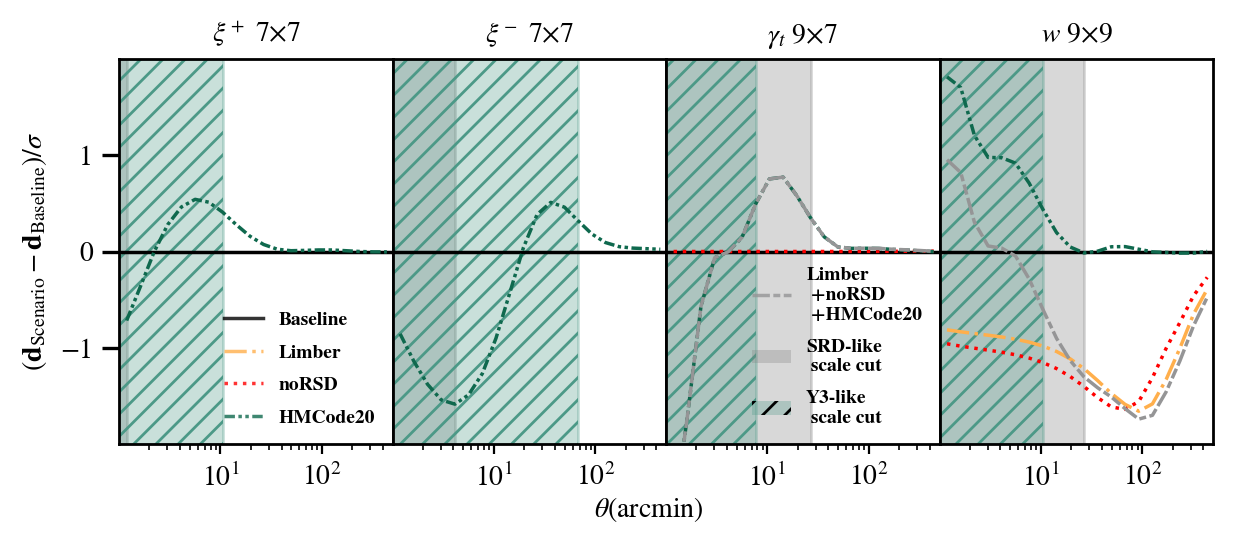

In [10]:
nlens = 10
nsrcs = 8
ntheta = 20

#thetas used in COCOA
tmin = 1.
tmax = 500.
vmin = tmin
vmax = tmax
N = ntheta
logdt = (np.log(vmax) - np.log(vmin))/N
fac = (2./3.)
thetas = []
for i in range(int(N)):
    thetamin = np.exp(np.log(vmin) + (i + 0.)*logdt)
    thetamax = np.exp(np.log(vmin) + (i + 1.)*logdt)
    thetas.append(fac * (thetamax**3 - thetamin**3) / (thetamax**2 - thetamin**2))
thetas = np.array(thetas)

probe_start = {'xip':0, 'xim':int(nsrcs*(nsrcs+1)/2), 'gammat':int(nsrcs*(nsrcs+1)), 'wtheta':int(nsrcs*(nsrcs+1)+nlens*nsrcs),}
def Ncombo(probe, ni, nj):
    start = probe_start[probe]
    sub_cnt = 0
    if probe in ['xip', 'xim']:
        for i in range(nsrcs):
            for j in range(i,nsrcs):
                if(i,j)==(ni,nj):
                    break
                sub_cnt+=1
                
    if probe == 'gammat':
        for i in range(nlens):
            for j in range(nsrcs):
                if(i,j)==(ni,nj):
                    break
                sub_cnt+=1
                
    if probe == 'wtheta':
        for i in range(nlens):
            if (i,i) == (ni,nj):
                break
            sub_cnt+=1
            
    return start+sub_cnt

ls_list = ['-', '-.', ':', (0, (3,1,1,1,1,1)), (0, (5, 1, 2, 1, 3, 1))]
c_list  = ['k', '#FFAF4C', 'r', '#0F694E', '#959596']
labels  = ['Baseline', 'Limber', 'noRSD', 'HMCode20', 'Limber\n +noRSD\n +HMCode20']
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Line2D([0], [0], ls=ls_list[i], lw=1.25, color=c_list[i],alpha=0.8, label=labels[i]) \
        for i in range(len(ls_list))
]
patch_handles = [
    Patch(facecolor='gray', alpha=0.3, label='SRD-like\n scale cut'),
    Patch(facecolor='#4C9987', alpha=0.3, hatch='///', label='Y3-like\n scale cut')
]
latexs = {'xip':r'$\xi^+$', 'xim':r'$\xi^-$', 'gammat':r'$\gamma_t$', 'wtheta':r'$w$',}
def plot_single(
    ax,
    dvs,
    probe,
    ni,
    nj,):
    assert probe in ['xip','xim','gammat','wtheta']
    assert ni>=0 and nj>=0
    assert ni<10 and nj<10
    assert type(ni) == int and type(nj) == int
    plot_dv = [True, True, True, True, True]
    if probe in ['xip', 'xim', 'gammat']:
        plot_dv[1] = False
    if probe in ['xip', 'xim']:
        plot_dv[2] = False
        plot_dv[4] = False
    #fetch the segment of dv and cov
    ncombo = Ncombo(probe,ni,nj)
    l,r = ncombo*ntheta, (ncombo+1)*ntheta
    dv_seg = dvs[:, l:r]
    cov_seg = cov[l:r,:][:,l:r]
    sigmas_seg = np.sqrt(np.array([cov_seg[i,i] for i in range(len(cov_seg))]))
    y3mask_seg = y3mask[l:r].astype(bool)
    srdmask_seg = srdmask[l:r].astype(bool)
    
    baseline = dv_seg[0]
    #plot reference line and shadow of mask
    ax.axhline(y=0.0, color='k',ls='-',linewidth=1.25)
    ax.axvspan(0, 0 if thetas[~srdmask_seg].size == 0 else thetas[~srdmask_seg][-1], color='gray', alpha=0.3, )
    ax.axvspan(0, 0 if thetas[~y3mask_seg].size == 0 else thetas[~y3mask_seg][-1], color='#4C9987', alpha=0.3, edgecolor='none')
    ax.axvspan(0, 0 if thetas[~y3mask_seg].size == 0 else thetas[~y3mask_seg][-1], facecolor='none', edgecolor='#4C9987', hatch='///', linewidth=0.0)
    invcov_seg = np.linalg.pinv(cov_seg)
    chi2s = []
    for i in range(1, len(dv_seg)):
        if plot_dv[i] == False:
            continue
        y = (dv_seg[i] - baseline)/sigmas_seg
        ax.plot(thetas, y, linestyle=ls_list[i],color = c_list[i], lw=1.25)
        
        chi2s.append((dv_seg[i] - baseline)@invcov_seg@(dv_seg[i] - baseline))
        
    ax.set_xlim(1+0.01, 500-0.01)
    ax.set_xscale('log')
    ax.set_ylim(-2+0.01,2-0.01)
    ax.set_title(latexs[probe]+fr' ${ni}{{\times}}{nj}$')
    
    return chi2s


fig,axs = plt.subplots(1,4, figsize=(textwidth,2.5), gridspec_kw={'width_ratios':[2,2,2,2]})
fig.supxlabel(r'$\theta(\mathrm{arcmin})$', fontsize=10, x=0.5, y=-0.05)
plt.subplots_adjust(wspace=0.00)
for i in range(1,4):
    axs[i].tick_params(axis='y', which='both', left=False,labelleft=False)
plot_single(axs[0], dvs, probe='xip',ni=7,nj=7)
plot_single(axs[1], dvs, probe='xim',ni=7,nj=7)
plot_single(axs[2], dvs, probe='gammat',ni=9,nj=7)
plot_single(axs[3], dvs, probe='wtheta',ni=9,nj=9)

axs[0].set_ylabel(r'$(\mathbf{d}_\mathrm{Scenario} - \mathbf{d}_\mathrm{Baseline})/\sigma$')
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
axs[0].yaxis.set_major_locator(MultipleLocator(1))

#axs[-1].axis('off')
#axs[-1].tick_params(axis='y', which='both', left=False,labelleft=False)
#axs[-1].tick_params(axis='x', which='both', bottom=False,labelbottom=False)
all_handles = handles+patch_handles
Len_handles = 8
axs[0].legend(handles=all_handles[:int(Len_handles/2)], frameon=False,loc='lower right',ncol=1, prop={'weight':'bold', 'size':7})
axs[2].legend(handles=all_handles[int(Len_handles/2):], frameon=False,loc='lower right',ncol=1, prop={'weight':'bold', 'size':7})

row_labels = labels
col_labels = [ 'y3-like \nscale cut', 'srd-like \n scale cut']
cell_text = []
for i in range(len(labels)):
    if i==2:
        cell_text.append([ f'{chi2s_y3mask[i]:.3f}', f'{chi2s_srdmask[i]:.3f}'])
    else:
        cell_text.append([ f'{chi2s_y3mask[i]:.1f}', f'{chi2s_srdmask[i]:.1f}'])
'''tbl = axs[-1].table(
    cellText=cell_text,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center',
    rowLoc='center',
    bbox=[0.45, 0.0, 1.0, 1.0], 
    edges='open',
)'''
#tbl.auto_set_font_size(False)
#tbl.set_fontsize(7)
#tbl.scale(1.0,0.5)

plt.savefig('3x2pt_dv_comparison_roman_real.pdf', dpi=300)

/scratch/local/jobs/47792017/ipykernel_2625984/2224633255.py:89: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(0, 0 if thetas[~y3mask_seg].size == 0 else thetas[~y3mask_seg][-1], color='#4C9987', alpha=0.3, edgecolor='none')


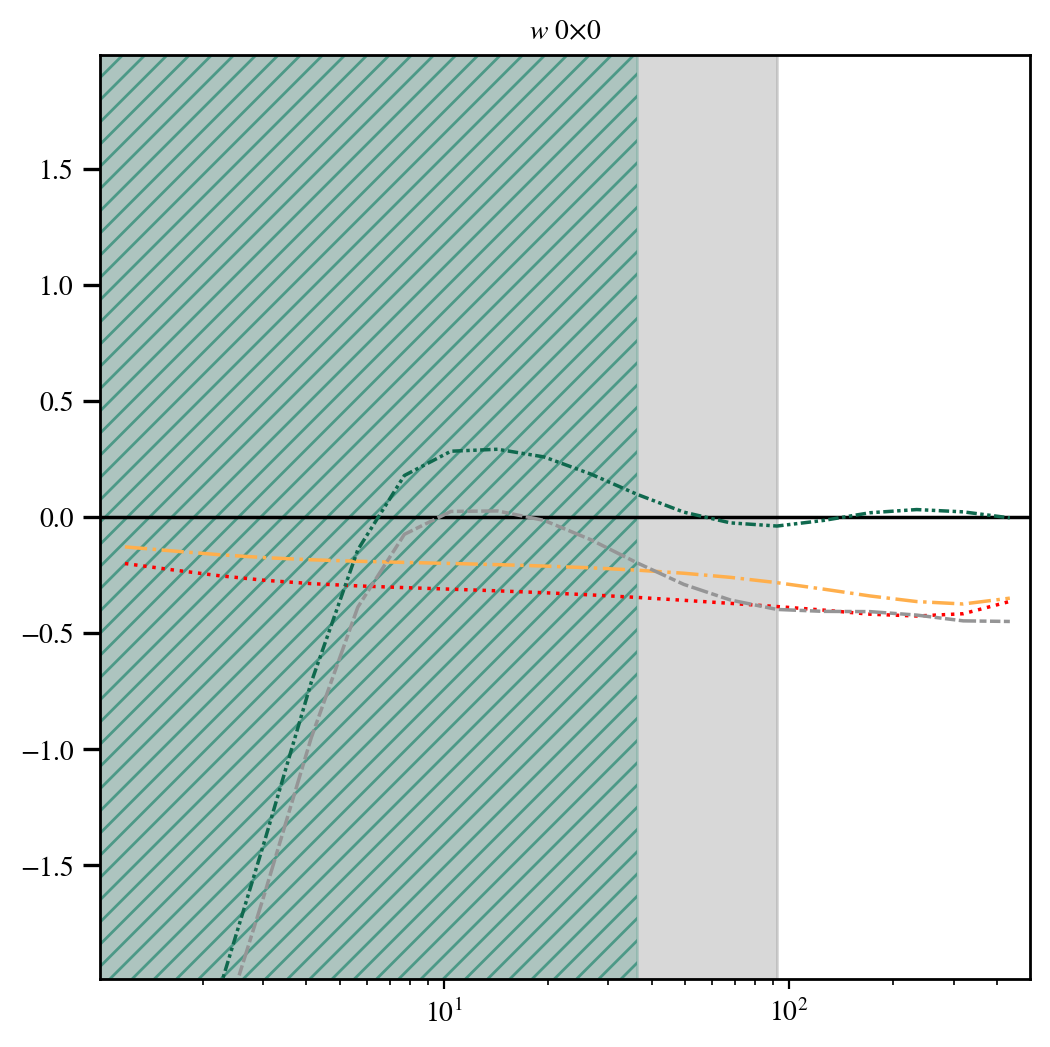

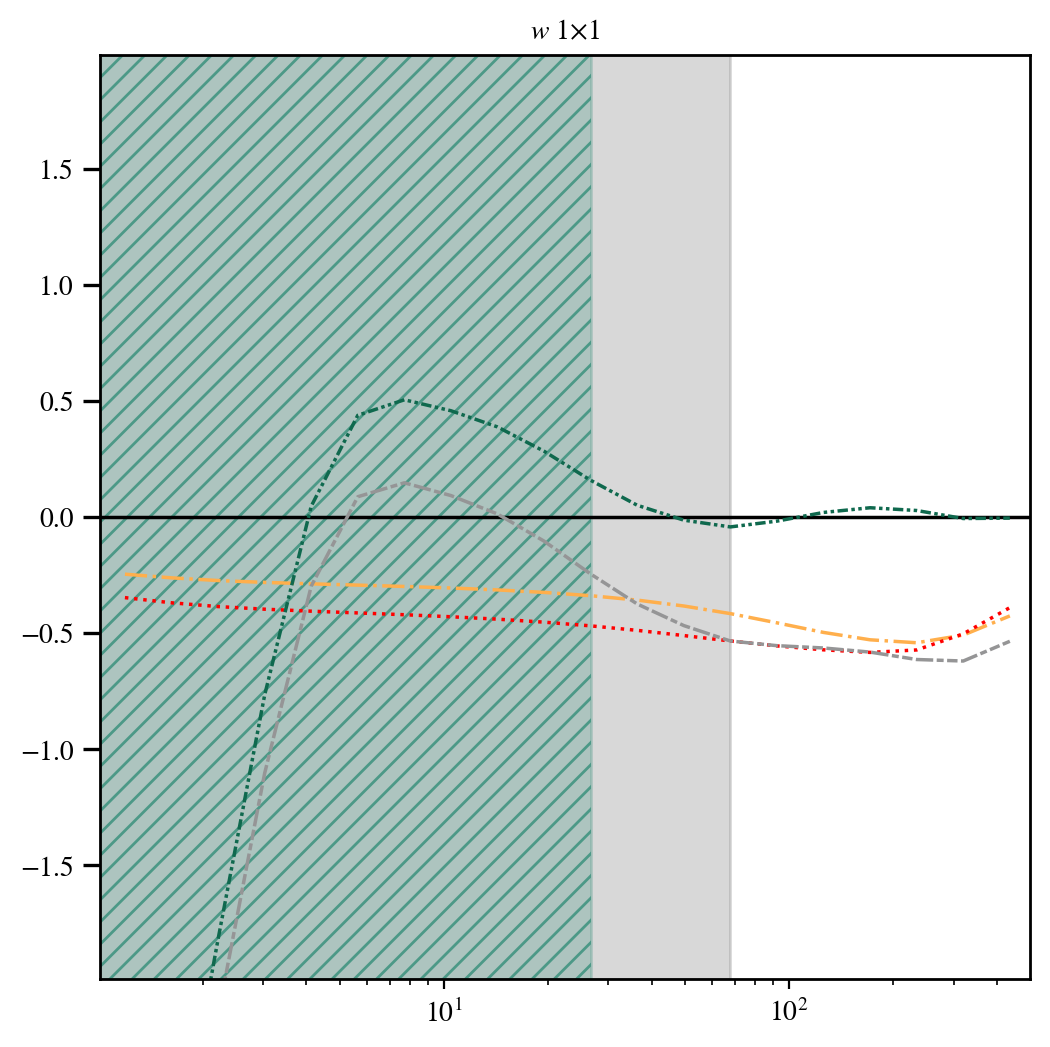

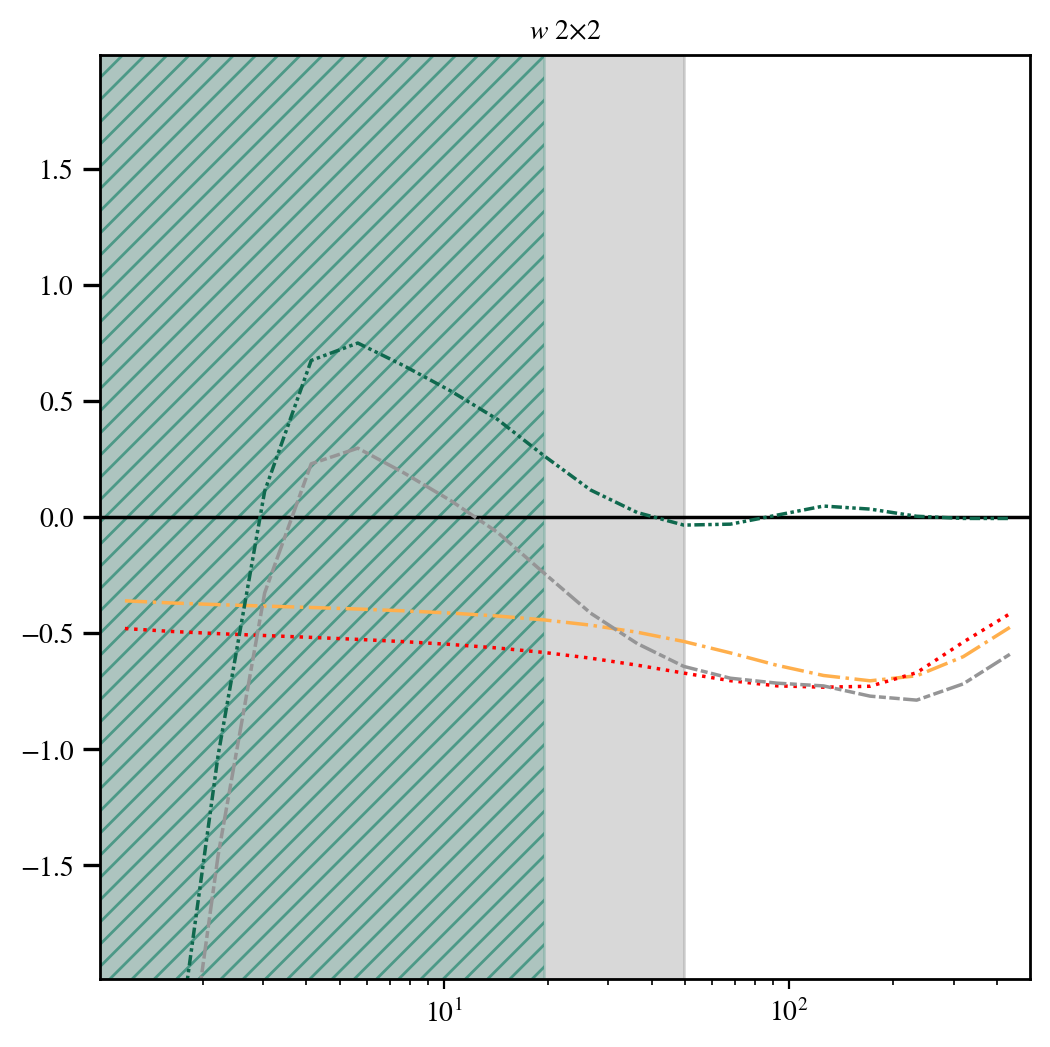

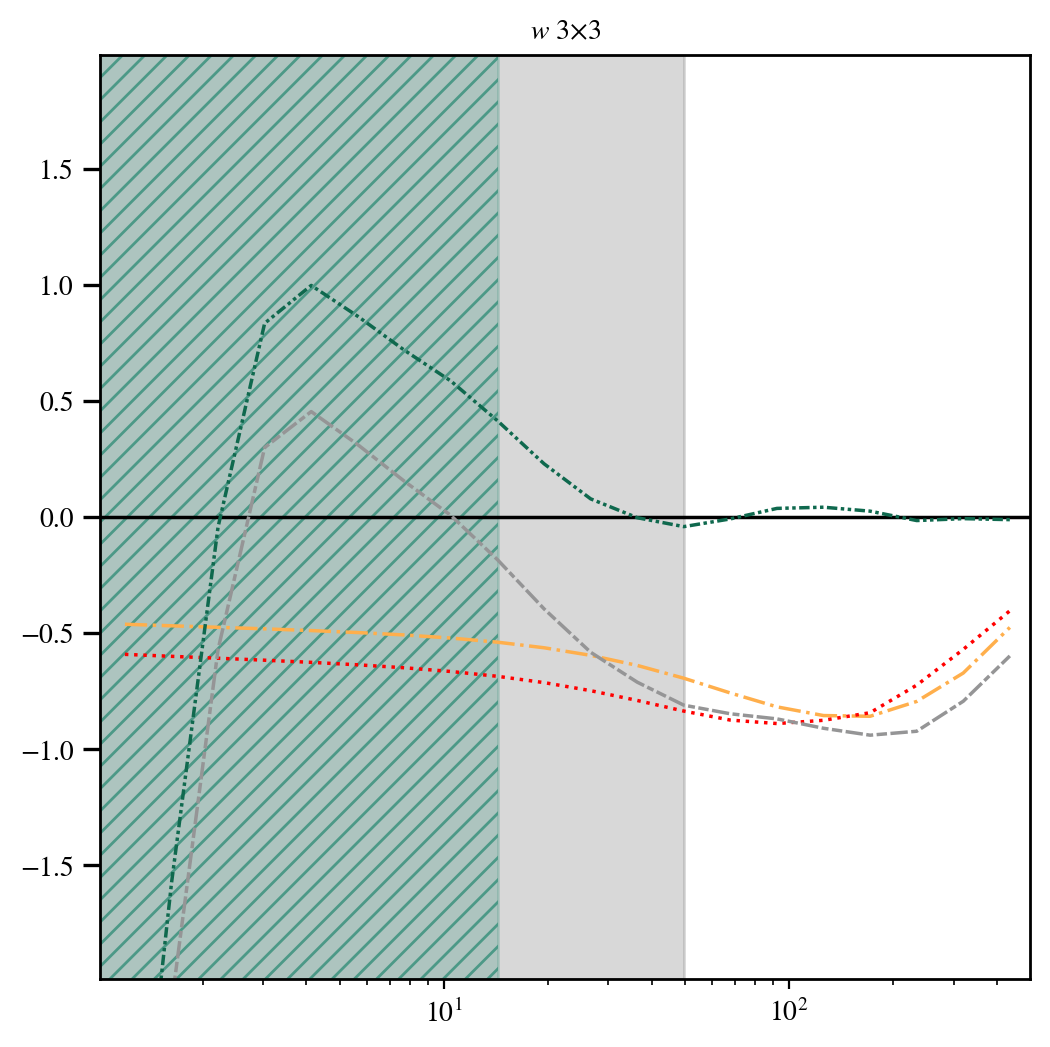

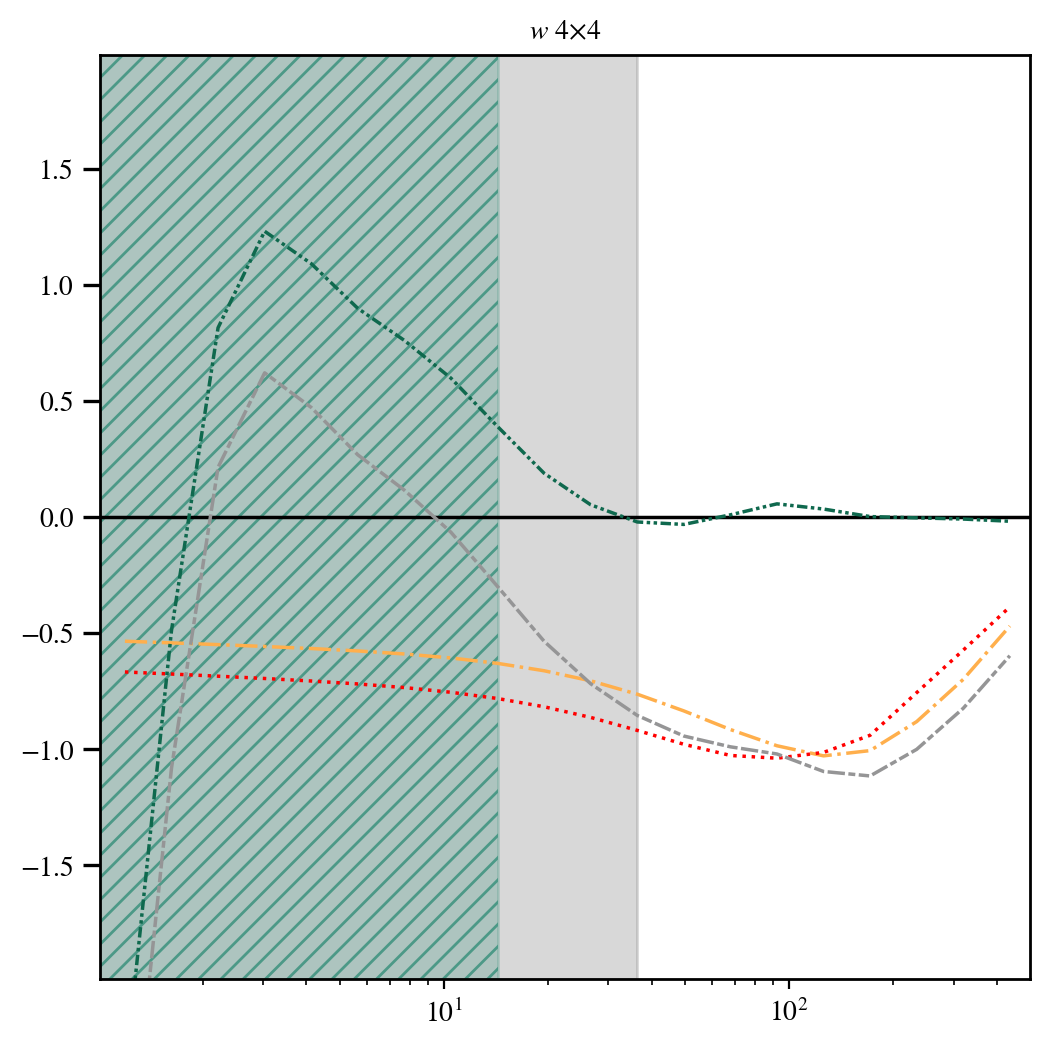

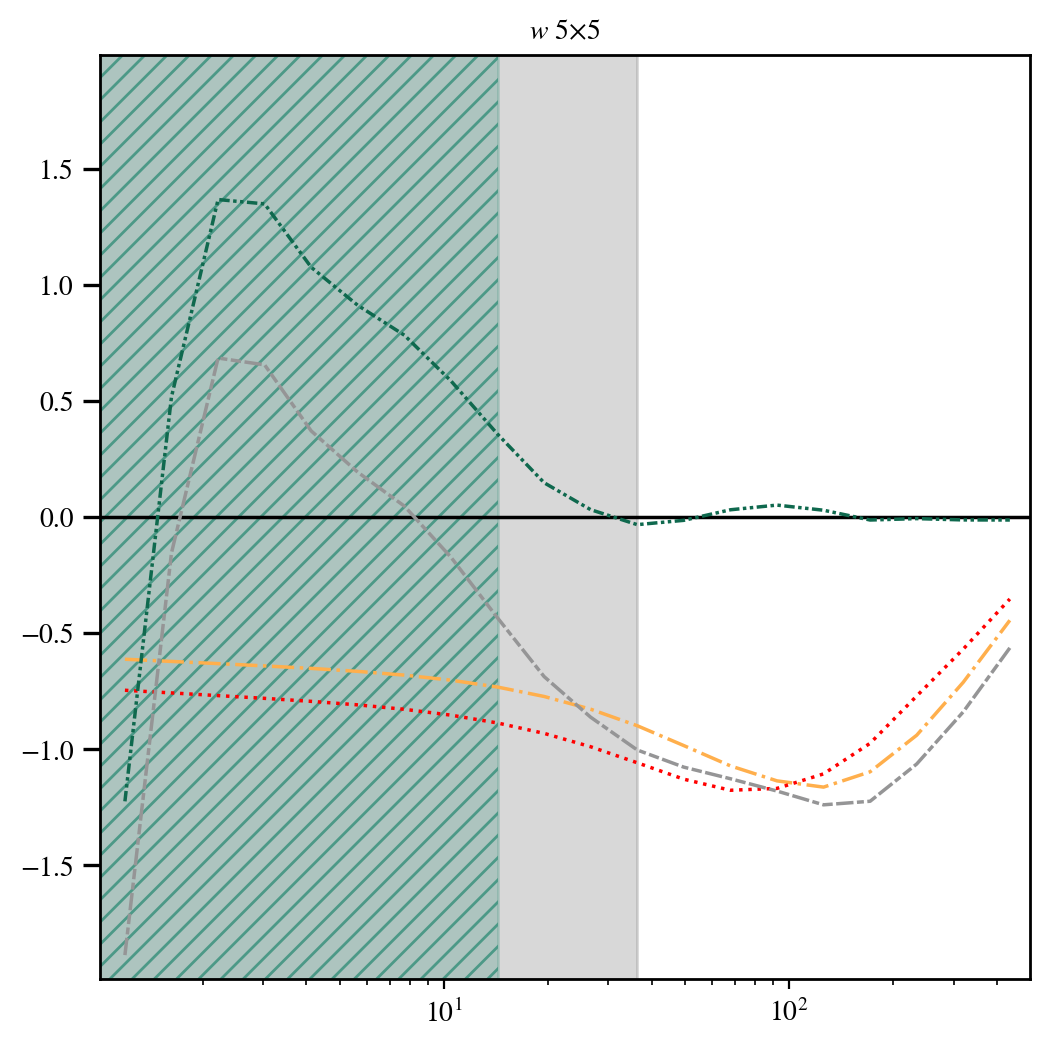

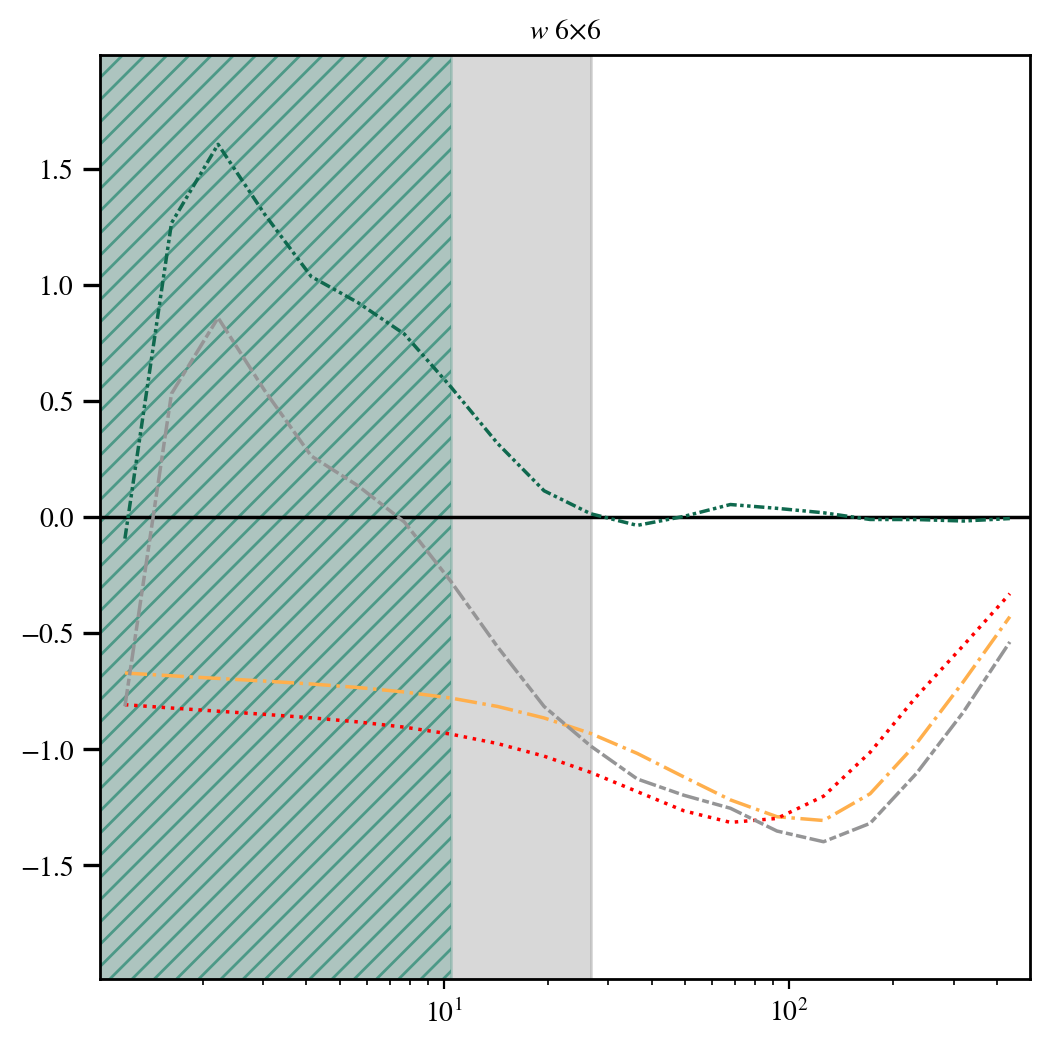

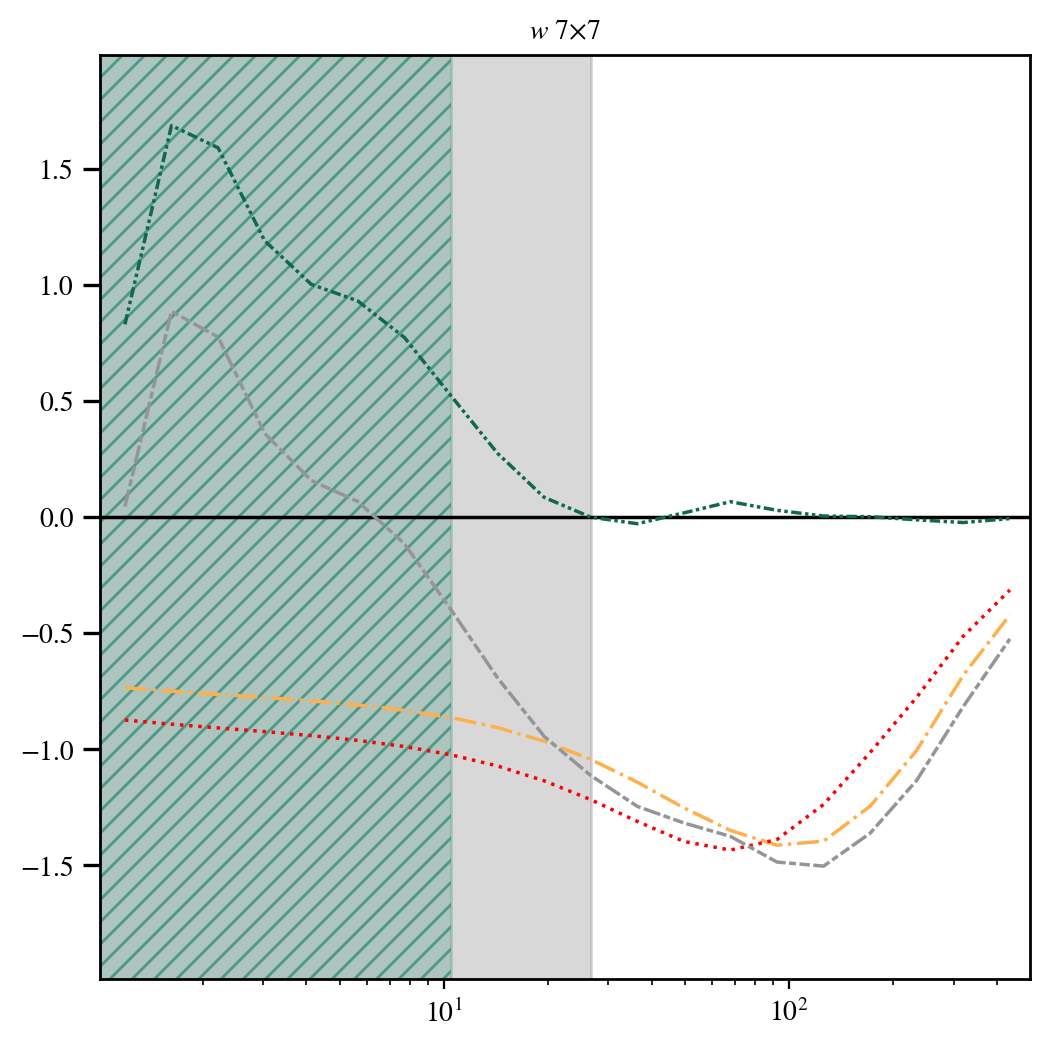

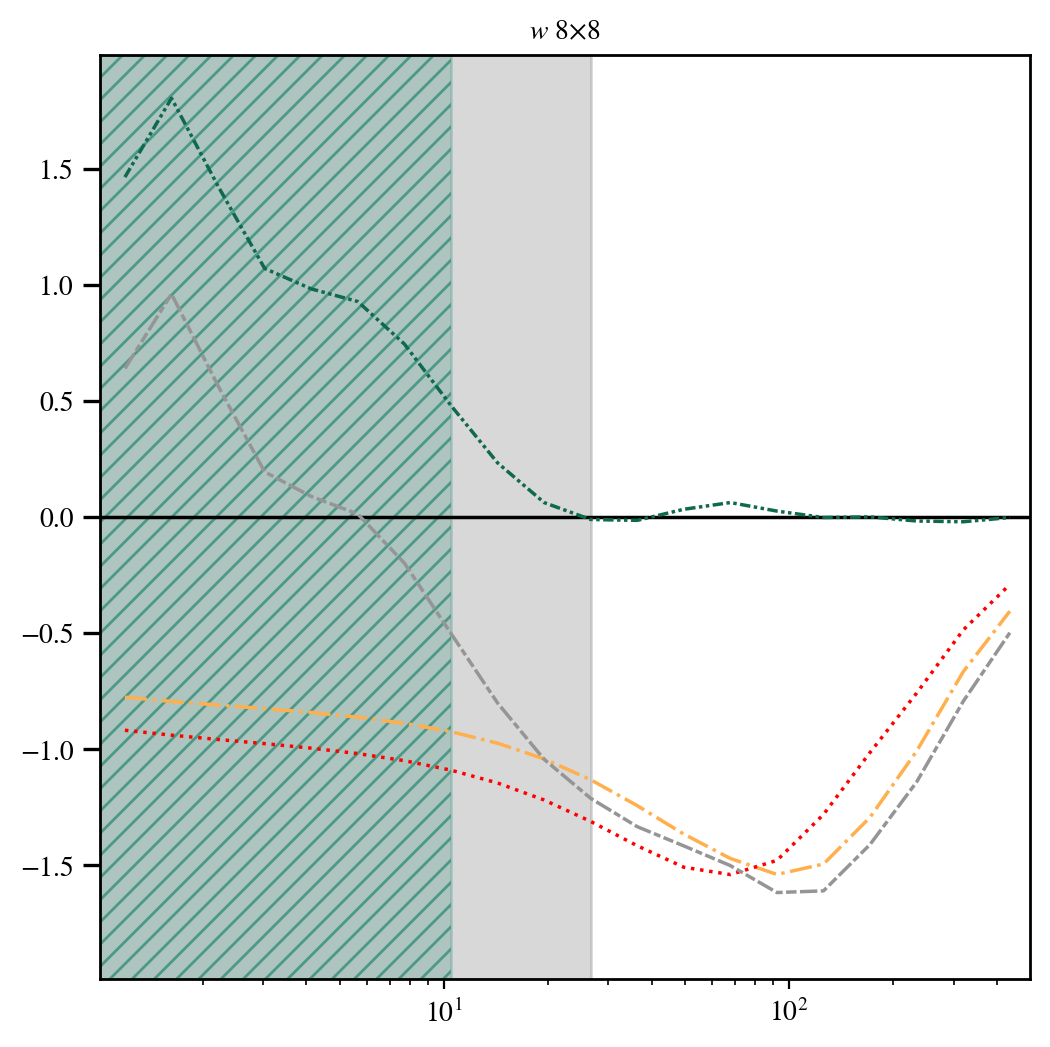

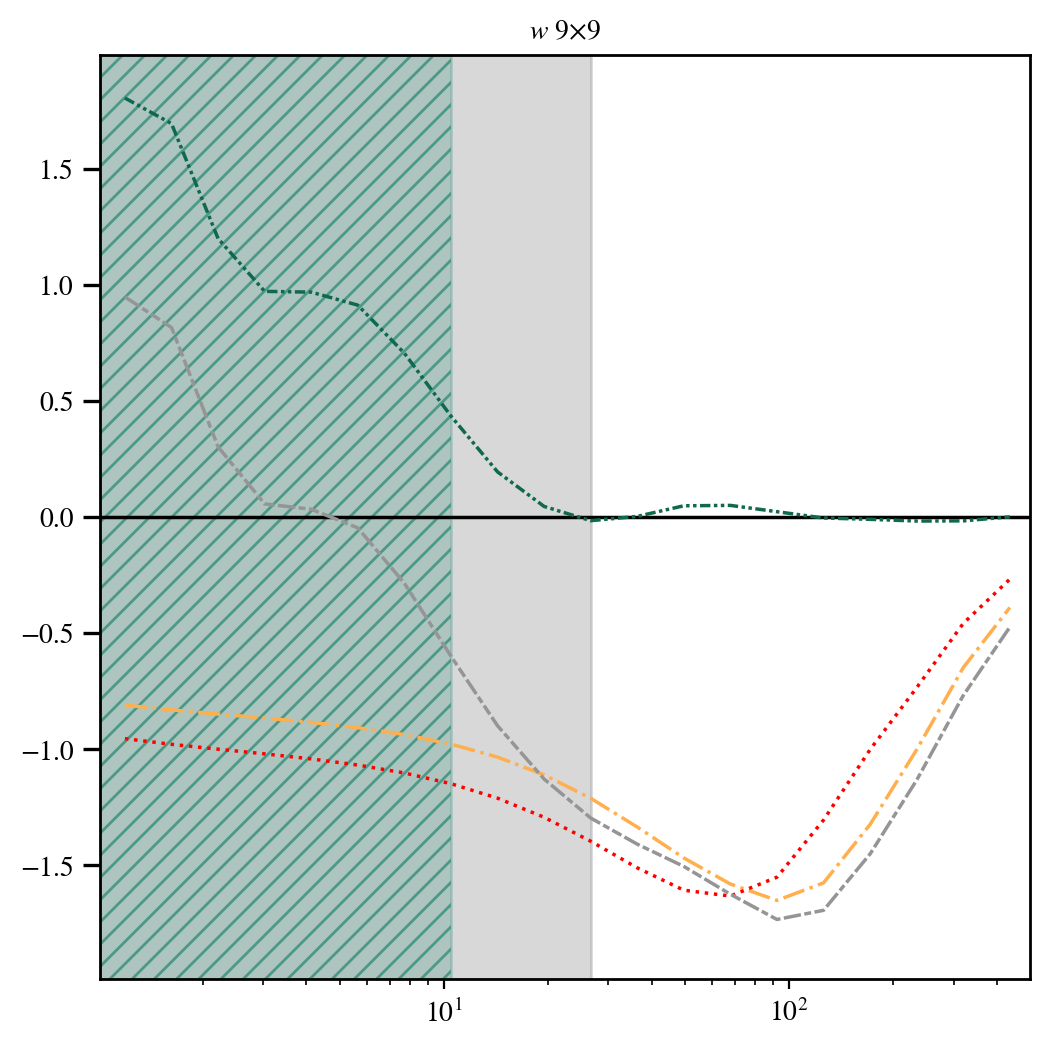

Max = 0; Maxi = 9; Maxj = 9


In [11]:
Max = 0
Maxi, Maxj = 0, 0

for i in range(nlens):
    fig,ax = plt.subplots(1,1, figsize=(6,6))
    chi2s = plot_single(ax, dvs, probe='wtheta',ni=i,nj=i)
    sumchi2s = np.sum(chi2s)
    if (sumchi2s>Max):
        Maxi = i
        Maxj = i
    plt.show()

print(f'Max = {Max}; Maxi = {Maxi}; Maxj = {Maxj}')